In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, ReLU, Dense, Flatten, Dropout
from tensorflow.keras.datasets import cifar10
from PIL import Image

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train=X_train[:10000]
X_test=X_test[:2000]
y_train=y_train[:10000]
y_test=y_test[:2000]

In [3]:
X_train = X_train.reshape(-1,32,32,3)/255
X_test = X_test.reshape(-1,32,32,3)/255


In [4]:
X_train.shape

(10000, 32, 32, 3)

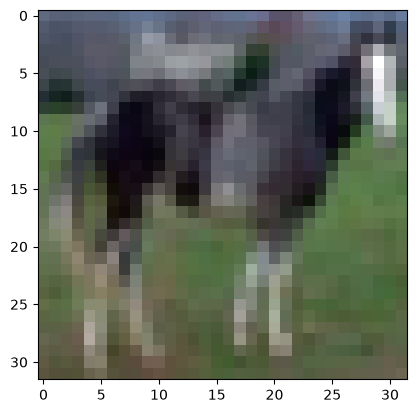

: 

In [ ]:
plt.imshow(X_train[37])

In [ ]:
cnn = Sequential([
    Conv2D(32,(3,3), input_shape=(32,32,3),activation="relu"),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3)),
    MaxPooling2D((2,2)),
    ReLU(),
    Conv2D(128,(3,3)),
    MaxPooling2D((2,2)),
    ReLU(),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation="relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(10, activation="softmax")
])
cnn.compile(optimizer="adam",loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn.fit(X_train, y_train, epochs =9, verbose=2, validation_data=(X_test, y_test), batch_size=32)

/workspaces/229404462/.venv-1/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1788098757.601840   76823 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [ ]:
objects ={
    0:"airplane",
    1:"automobile",
    2:"bird",
    3:"cat",
    4:"deer",
    5:"dog",
    6:"frog",
    7:"horse",
    8:"ship",
    9:"truck"
}

In [ ]:
def pred(file):
    img = Image.open(file).convert("RGB")
    img = img.resize((32,32))
    img_array= np.array(img)/255.0
    img_array= np.expand_dims(img_array, axis=0)
    pred = cnn.predict(img_array)
    pred_max = np.argmax(pred)
    objectss = objects[pred_max]
    print("Pred Number: ", pred_max)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Pred Image: {objectss}")
    plt.show()
inputt = input("Enter the file path of the image you want to make a prediction for: ")
pred(inputt)

In [ ]:
test_loss, test_acc = cnn.evaluate(X_test, y_test, verbose=1)
print("Model Doğruluğu: ", test_acc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5375 - loss: 1.2982
Model Doğruluğu:  0.5375000238418579
